In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("sales_data_with_discounts.csv")
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


Numerical & Categorical Columns

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
categorical_cols = df.select_dtypes(include=['object'])

numerical_cols.columns, categorical_cols.columns

(Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
        'Discount Amount', 'Net Sales Value'],
       dtype='object'),
 Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object'))

Descriptive Statistics Calculate

In [ ]:
stats = pd.DataFrame({
    "Mean": numerical_cols.mean(),
    "Median": numerical_cols.median(),
    "Mode": numerical_cols.mode().iloc[0],
    "Standard Deviation": numerical_cols.std()
})

stats


,Mean,Median,Mode,Standard Deviation
Volume,5.066667,4.000000,3.000000,4.231602
Avg Price,10453.433333,1450.000000,400.000000,18079.904840
Total Sales Value,33812.835556,5700.000000,24300.000000,50535.074173
Discount Rate (%),15.155242,16.577766,5.007822,4.220602
Discount Amount,3346.499424,988.933733,69.177942,4509.902963
Net Sales Value,30466.336131,4677.788059,326.974801,46358.656624


Histograms (Distribution Check)

In [ ]:
import matplotlib.pyplot as plt

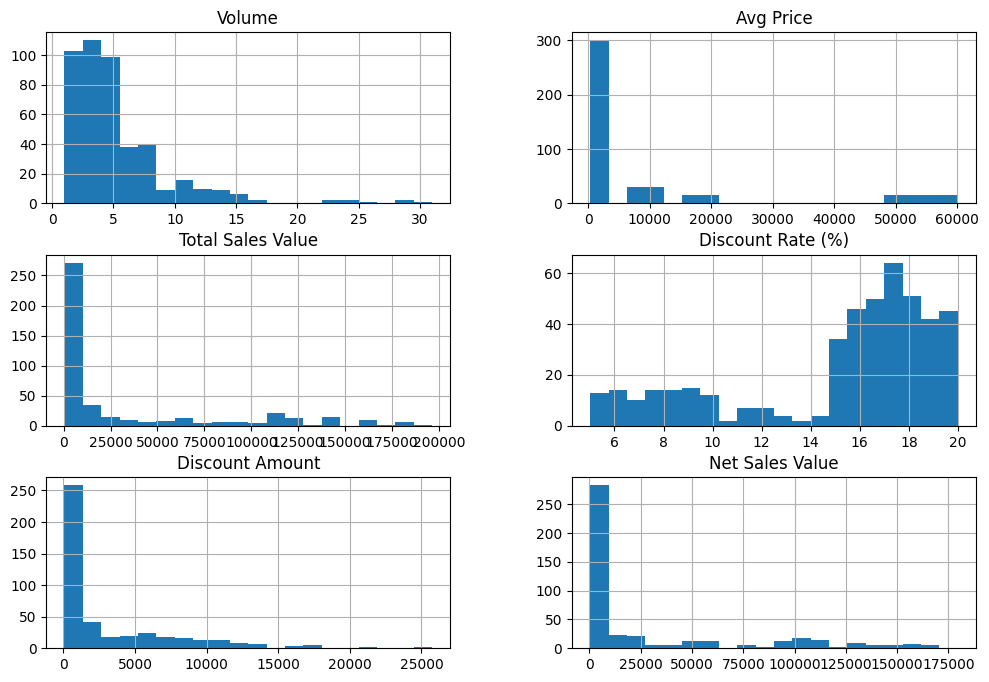

In [ ]:
numerical_cols.hist(bins=20, figsize=(12,8))
plt.show()

Boxplots (Outliers Identify)

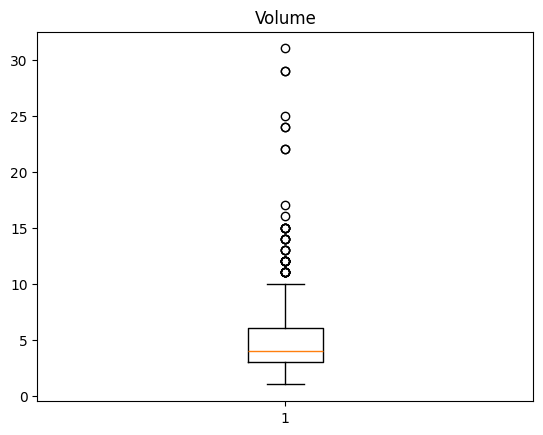

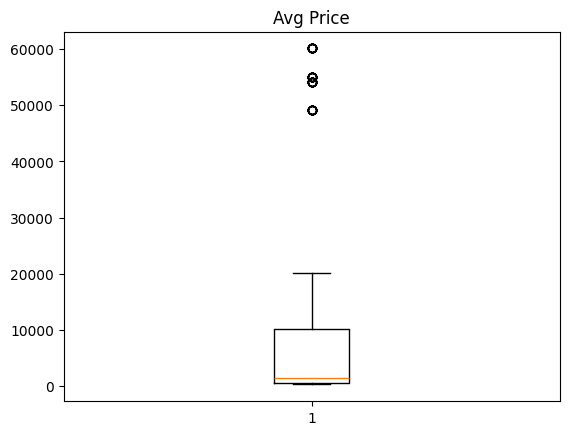

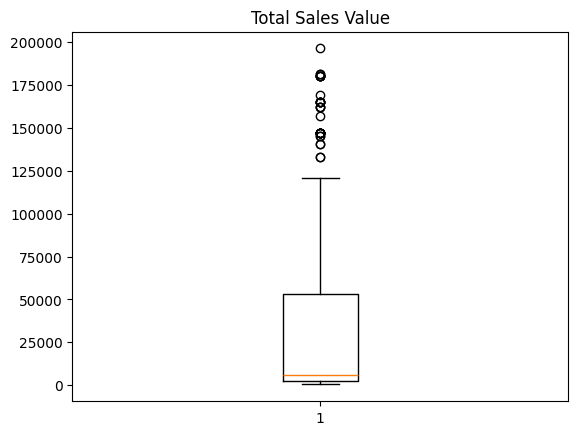

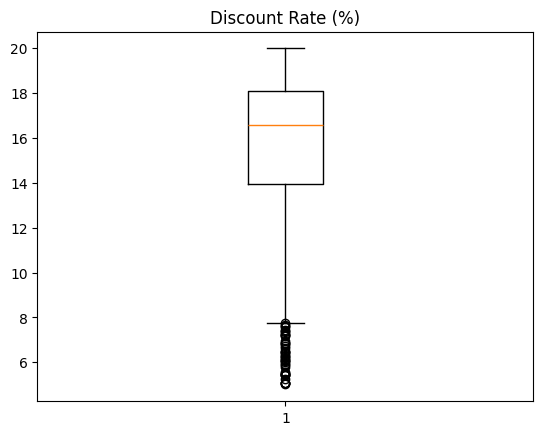

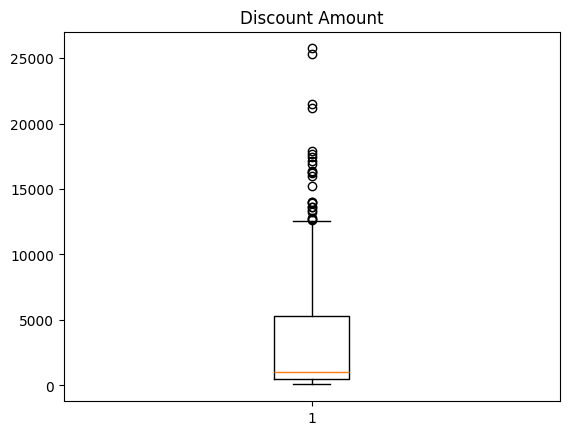

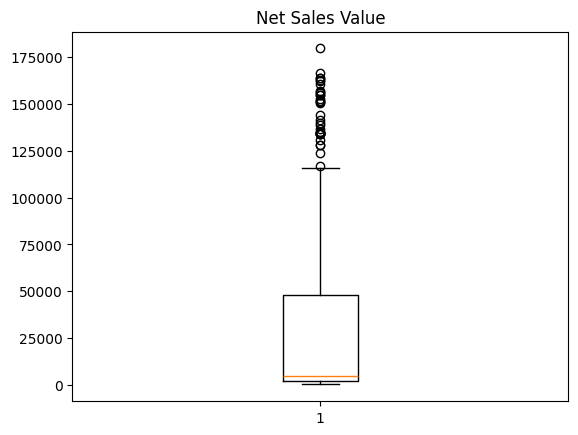

In [ ]:
for col in numerical_cols.columns:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()


Bar Charts (Categorical Columns)

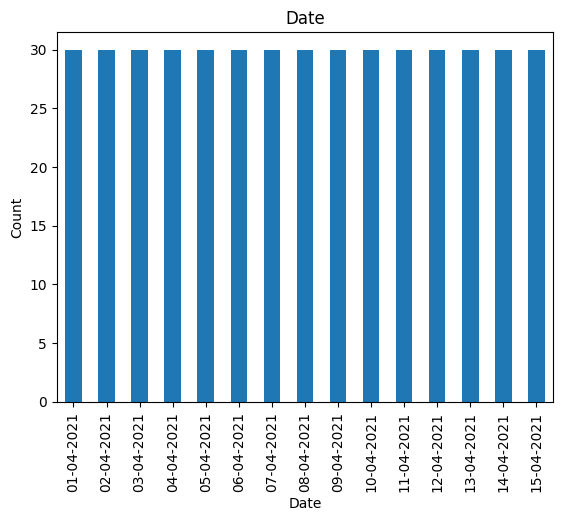

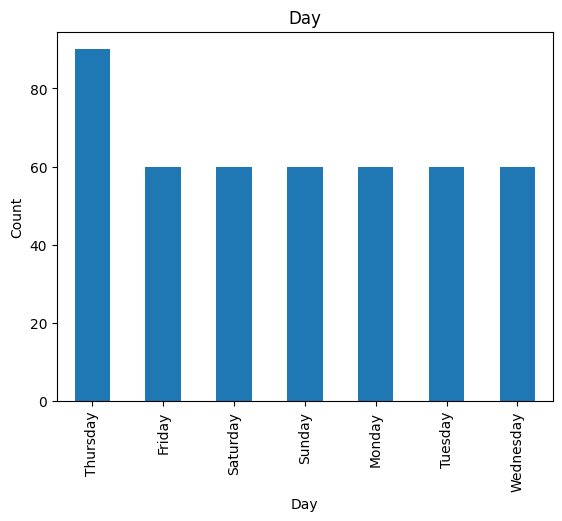

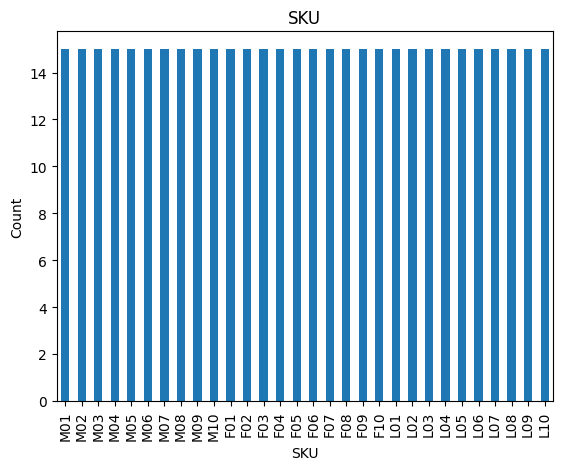

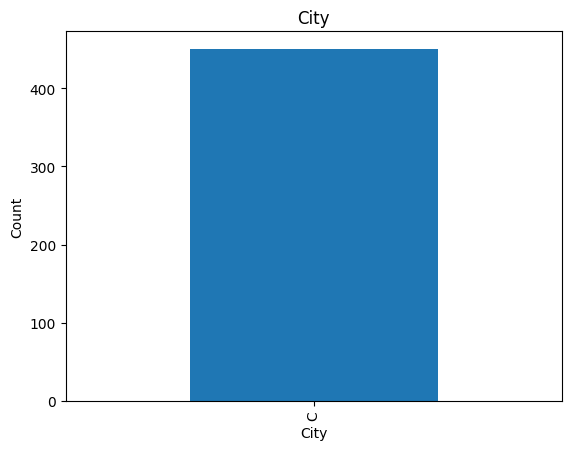

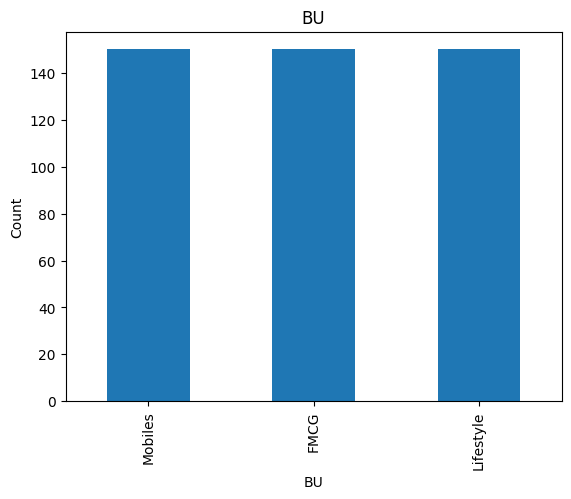

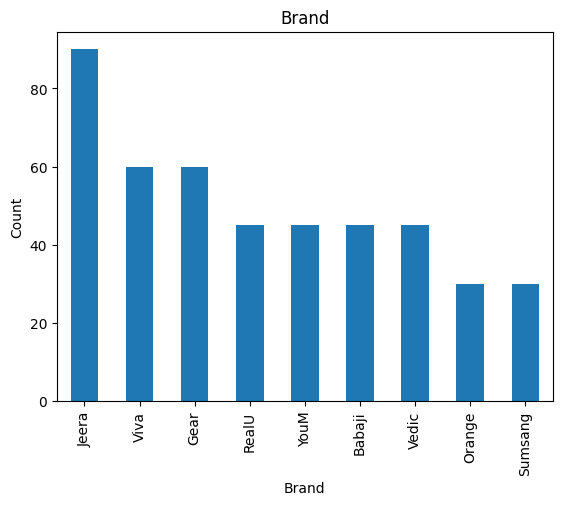

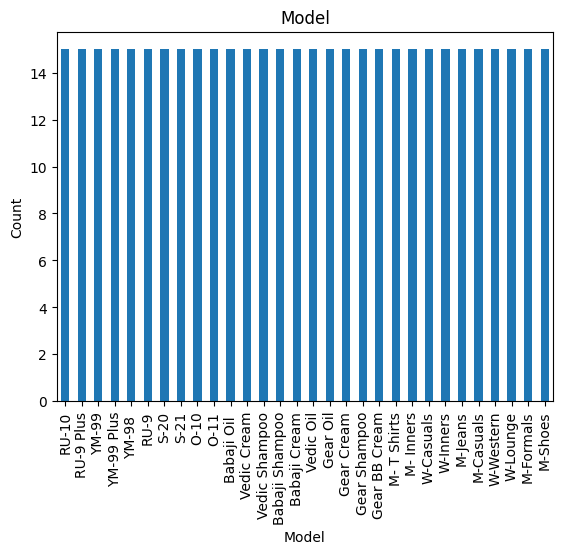

In [ ]:
for col in categorical_cols.columns:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


Standardization (Z-Score)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_cols)

In [ ]:
standardized_df = pd.DataFrame(scaled_data,columns=numerical_cols.columns)
standardized_df.head()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,2.350029,0.091173,2.925721,-0.830289,3.952816,2.804756
1,1.167129,-0.019570,1.330995,-0.852661,1.849014,1.271026
2,0.457388,0.312659,1.562775,-1.351631,1.622995,1.545675
3,0.220808,0.534146,1.719276,-1.949723,1.113807,1.765810
4,-0.488932,-0.130313,-0.188452,0.673739,0.227852,-0.227595


In [ ]:
encoded_df = pd.get_dummies(df, columns=categorical_cols.columns, drop_first=True)
encoded_df.head()


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,Date_05-04-2021,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,15,12100,181500,11.654820,21153.498820,160346.501180,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,10,10100,101000,11.560498,11676.102961,89323.897039,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,7,16100,112700,9.456886,10657.910157,102042.089843,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,6,20100,120600,6.935385,8364.074702,112235.925298,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3,8100,24300,17.995663,4372.946230,19927.053770,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


# Conclusion

This analysis provided valuable insights into the Sales & Discounts dataset using descriptive statistics and data visualization techniques. The calculation of mean, median, mode, and standard deviation helped in understanding the central tendency and variability of numerical features. Histograms revealed the distribution patterns of data, including skewness and potential outliers, while boxplots clearly identified extreme values and spread using the interquartile range. Bar charts helped in understanding the distribution and frequency of categorical variables, highlighting dominant categories and patterns in the dataset.

Data preprocessing played a crucial role in preparing the dataset for further analysis and machine learning. Standardization ensured that numerical variables were scaled uniformly, preventing features with larger values from dominating the model. One-hot encoding transformed categorical variables into a numerical format, making them suitable for machine learning algorithms.

Overall, these preprocessing steps improve the accuracy, efficiency, and reliability of analytical models, making them essential in any data analysis and machine learning workflow.